<a href="https://colab.research.google.com/github/tjdux/Introduction-to-Machine-Learning-with-Python/blob/main/06_1_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EC%A0%84%EC%B2%98%EB%A6%AC%EC%99%80_%EB%A7%A4%EA%B0%9C%EB%B3%80%EC%88%98_%EC%84%A0%ED%83%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 노트북이 코랩에서 실행 중인지 체크합니다.
import os
import sys
if 'google.colab' in sys.modules and not os.path.isdir('mglearn'):
    # mglearn을 다운받고 압축을 풉니다.
    !wget -q -O mglearn.tar.gz https://bit.ly/mglearn-tar-gz
    !tar -xzf mglearn.tar.gz
    !wget -q -O data.tar.gz https://bit.ly/data-tar-gz
    !tar -xzf data.tar.gz
    # 나눔 폰트를 설치합니다.
    !sudo apt-get -qq -y install fonts-nanum
    import matplotlib.font_manager as fm
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 117528 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [2]:
import sklearn
from preamble import *
import matplotlib

# 나눔 폰트를 사용합니다.
matplotlib.rc('font', family='NanumBarunGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

/content/mglearn/datasets.py:31: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [3]:
# 데이터 로드, 스케일 조정
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0
)

scaler = MinMaxScaler().fit(X_train) # 😣

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
# GridSearchCV를 사용하여 더 좋은 SVC 매개변수 찾기
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100],
              "gamma": [0.001, 0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(SVC(), param_grid=param_grid, cv=5)
grid.fit(X_train_scaled, y_train) # 😣

print(f"최상의 교차 검증 정확도: {round(grid.best_score_, 2)}")
print(f"테스트 점수: {round(grid.score(X_test_scaled, y_test), 2)}")
print(f"최적의 매개변수: {grid.best_params_}")

최상의 교차 검증 정확도: 0.98
테스트 점수: 0.97
최적의 매개변수: {'C': 1, 'gamma': 1}


- 문제점
  - 전처리 과정에서 훈련 세트 전체를 사용
  - 스테일이 조정된 훈련 데이터에서 교차 검증을 사용해 그리드 서치를 수행
- 교차 검증에서 원본 훈련 세트의 어떤 부분은 훈련 폴드가 되고 어떤 부분은 검증 폴드가 됨 ➡️ 데이터 스케일을 조정할 때 검증 폴드에 들어 있는 정보까지 이미 사용해버림
- 새로운 데이터가 관측되면 (테스트 세트처럼) 이 데이터는 훈련 데이터의 스케일 조정에 사용되지 않은 것이라 최솟값과 최댓값이 훈련 데이터와 다를 수 있음

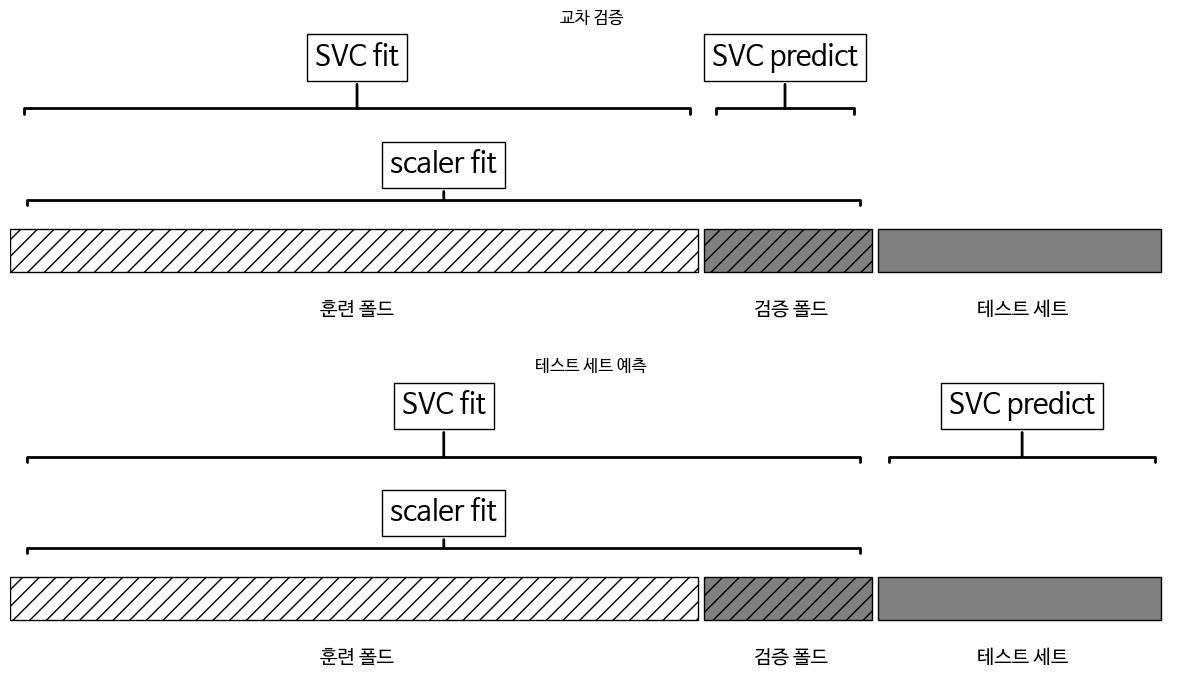

In [5]:
# 교차 검증 반복 밖에서 전처리가 될 때 데이터 사용 형태
mglearn.plots.plot_improper_processing()

- 검증 폴더의 정보가 모델 구축과정에서 누설되었으므로 교차 검증에서 최적의 매개변수를 찾지 못하고 낙관적인 결과가 만들어짐
- 문제를 해결하기 위해 교차 검증의 분할이 모든 전처리 과정보다 앞서 이루어져야 함
- `Pipeline`
  - 여러 처리 단계를 하나의 scikit-learn 추정기 형태로 묶어주는 파이썬 클래스
  - 지도 학습 모델과 전처리 단계를 연결할 때 사용